# CIFAR-10 CNN Classifier - Task 3 (Regularization Experiments)

This notebook completes **Task 3A** and **Task 3B** from the assignment PDF using the required training settings.

## Task 3 Requirements Checklist

- 3A: Compare dropout configurations D0, D1, D2 using the Medium model from Task 2A
- 3A config: 30 epochs, Adam(lr=0.001), batch_size=128
- 3A outputs: results table, overfitting gap, val-accuracy plot, train-accuracy plot, conclusion
- 3B: Compare early stopping ES0/ES2/ES3 using D0 (no dropout)
- 3B config: ES0=50 epochs, ES2 patience=5, ES3 patience=10, monitor='val_loss', restore_best_weights=True
- 3B outputs: results table, val-loss plot with stopping lines, conclusion

In [5]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers, models, callbacks, optimizers
from keras.datasets import cifar10
from keras.utils import to_categorical

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


In [6]:
# Load CIFAR-10 and apply fixed split: 40k train, 10k val, 10k test
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

x_train = x_train_full[:40000].astype('float32')
y_train = y_train_full[:40000]
x_val = x_train_full[40000:].astype('float32')
y_val = y_train_full[40000:]
x_test = x_test.astype('float32')

print(f'Train: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}')
print(f'Pixel range before preprocessing: [{x_train.min()}, {x_train.max()}]')

Train: (40000, 32, 32, 3) | Val: (10000, 32, 32, 3) | Test: (10000, 32, 32, 3)
Pixel range before preprocessing: [0.0, 255.0]


In [7]:
# Standardization (required by the assignment setup for this phase)
train_mean = x_train.mean(axis=(0, 1, 2))
train_std = x_train.std(axis=(0, 1, 2))

def standardize(x):
    return (x.astype('float32') - train_mean) / train_std

x_train_std = standardize(x_train)
x_val_std = standardize(x_val)
x_test_std = standardize(x_test)

print('Per-channel mean (train):', train_mean)
print('Per-channel std  (train):', train_std)

Per-channel mean (train): [125.32014  122.925385 113.78766 ]
Per-channel std  (train): [63.027916 62.145065 66.73145 ]


In [8]:
def build_medium_model(dropout_rate=0.0):
    """
    Medium model from Task 2A: Conv32-Conv32-Pool-Conv64-Conv64-Pool-Flatten-Dense256-Dense10.

    Dropout behavior for Task 3A:
    - D0: no dropout
    - D1/D2: dropout after each MaxPool and before output Dense
    """
    m = models.Sequential()
    m.add(layers.Input(shape=(32, 32, 3)))

    m.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    m.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    m.add(layers.MaxPooling2D((2, 2)))
    if dropout_rate > 0:
        m.add(layers.Dropout(dropout_rate))

    m.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    m.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    m.add(layers.MaxPooling2D((2, 2)))
    if dropout_rate > 0:
        m.add(layers.Dropout(dropout_rate))

    m.add(layers.Flatten())
    m.add(layers.Dense(256, activation='relu'))
    if dropout_rate > 0:
        m.add(layers.Dropout(dropout_rate))
    m.add(layers.Dense(10, activation='softmax'))

    m.compile(
        optimizer=optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return m

def train_and_evaluate(model, x_tr, y_tr, x_v, y_v, x_te, y_te, epochs, batch_size, cbs=None):
    if cbs is None:
        cbs = []

    y_tr_oh = to_categorical(y_tr, 10)
    y_v_oh = to_categorical(y_v, 10)
    y_te_oh = to_categorical(y_te, 10)

    start = time.time()
    history = model.fit(
        x_tr, y_tr_oh,
        validation_data=(x_v, y_v_oh),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=cbs,
        verbose=0
    )
    elapsed = time.time() - start

    test_loss, test_acc = model.evaluate(x_te, y_te_oh, verbose=0)
    return history, float(test_acc), float(test_loss), float(elapsed)

## Task 3A - Dropout Rate Comparison

In [9]:
# Required training config for Task 3A
EPOCHS_3A = 30
BATCH_SIZE = 128

dropout_configs = {
    'D0': 0.0,
    'D1': 0.25,
    'D2': 0.5
}

dropout_histories = {}
dropout_metrics = []

for name, rate in dropout_configs.items():
    print(f'Training {name} with dropout_rate={rate} ...')
    model = build_medium_model(dropout_rate=rate)
    hist, test_acc, test_loss, elapsed = train_and_evaluate(
        model,
        x_train_std, y_train,
        x_val_std, y_val,
        x_test_std, y_test,
        epochs=EPOCHS_3A,
        batch_size=BATCH_SIZE
    )

    train_acc_last = float(hist.history['accuracy'][-1])
    val_acc_last = float(hist.history['val_accuracy'][-1])
    overfit_gap = train_acc_last - val_acc_last

    dropout_histories[name] = hist
    dropout_metrics.append({
        'Model': name,
        'Train Acc': train_acc_last,
        'Val Acc': val_acc_last,
        'Test Acc': test_acc,
        'Overfit Gap': overfit_gap
    })

    print(f'  Done {name} | Test Acc={test_acc:.4f} | Gap={overfit_gap:.4f} | Time={elapsed:.1f}s')

Training D0 with dropout_rate=0.0 ...
  Done D0 | Test Acc=0.7223 | Gap=0.2708 | Time=333.5s
Training D1 with dropout_rate=0.25 ...
  Done D1 | Test Acc=0.7704 | Gap=0.1462 | Time=361.8s
Training D2 with dropout_rate=0.5 ...
  Done D2 | Test Acc=0.7887 | Gap=0.0026 | Time=359.0s


In [10]:
# Deliverable 18: Results table
dropout_df = pd.DataFrame(dropout_metrics)
dropout_df = dropout_df[['Model', 'Train Acc', 'Val Acc', 'Test Acc', 'Overfit Gap']]
dropout_df = dropout_df.sort_values('Model').reset_index(drop=True)
display(dropout_df.style.format({
    'Train Acc': '{:.4f}',
    'Val Acc': '{:.4f}',
    'Test Acc': '{:.4f}',
    'Overfit Gap': '{:.4f}'
}))

best_test_row = dropout_df.loc[dropout_df['Test Acc'].idxmax()]
smallest_gap_row = dropout_df.loc[dropout_df['Overfit Gap'].idxmin()]

print(f"Best Test Accuracy: {best_test_row['Model']} ({best_test_row['Test Acc']:.4f})")
print(f"Smallest Overfit Gap: {smallest_gap_row['Model']} ({smallest_gap_row['Overfit Gap']:.4f})")

,Model,Train Acc,Val Acc,Test Acc,Overfit Gap
0,D0,0.9926,0.7218,0.7223,0.2708
1,D1,0.9209,0.7747,0.7704,0.1462
2,D2,0.7998,0.7972,0.7887,0.0026


Best Test Accuracy: D2 (0.7887)
Smallest Overfit Gap: D2 (0.0026)


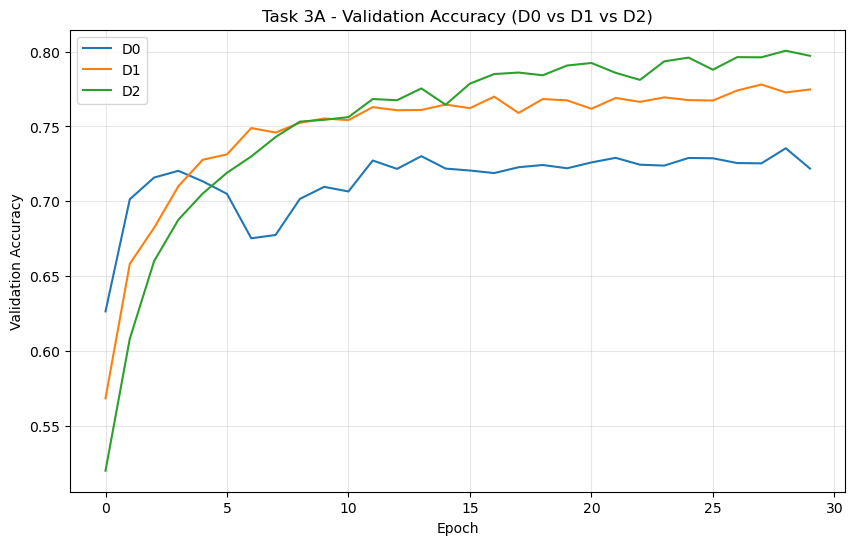

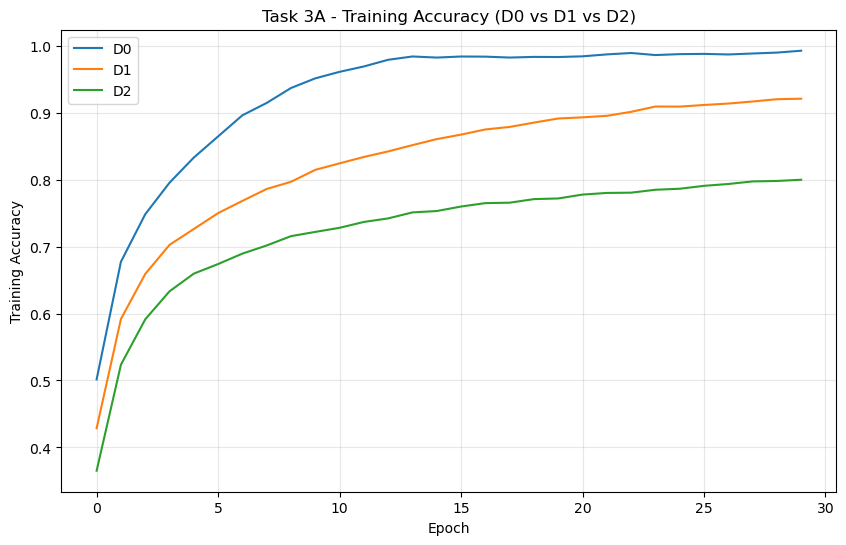

In [11]:
# Deliverable 19: all 3 validation accuracy curves on one plot
plt.figure(figsize=(10, 6))
for name in ['D0', 'D1', 'D2']:
    plt.plot(dropout_histories[name].history['val_accuracy'], label=name)
plt.title('Task 3A - Validation Accuracy (D0 vs D1 vs D2)')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Deliverable 20: all 3 training accuracy curves on one plot
plt.figure(figsize=(10, 6))
for name in ['D0', 'D1', 'D2']:
    plt.plot(dropout_histories[name].history['accuracy'], label=name)
plt.title('Task 3A - Training Accuracy (D0 vs D1 vs D2)')
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Task 3A Conclusion (Deliverable 21)

- Best test accuracy: **D2 (0.7887)**
- Smallest overfitting gap: **D2 (0.0026)**

Typical behavior:
- D0 often overfits more (higher train acc with lower val acc).
- D2 (0.5) can regularize strongly but may underfit.
- D1 (0.25) usually provides a better balance between generalization and capacity.

## Task 3B - Early Stopping Comparison (Using D0 Model)

In [12]:
BATCH_SIZE = 128

early_stop_configs = {
    'ES0': None,
    'ES2': callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    'ES3': callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
}

es_histories = {}
es_metrics = []

for exp_name, es_cb in early_stop_configs.items():
    print(f'Training {exp_name} ...')
    model = build_medium_model(dropout_rate=0.0)  # D0 model

    cb_list = [es_cb] if es_cb is not None else []
    hist, test_acc, test_loss, elapsed = train_and_evaluate(
        model,
        x_train_std, y_train,
        x_val_std, y_val,
        x_test_std, y_test,
        epochs=50,
        batch_size=BATCH_SIZE,
        cbs=cb_list
    )

    stopped_epoch = len(hist.history['loss'])
    best_val_loss = float(np.min(hist.history['val_loss']))

    es_histories[exp_name] = hist
    es_metrics.append({
        'Experiment': exp_name,
        'Stopped at Epoch': stopped_epoch,
        'Best Val Loss': best_val_loss,
        'Test Acc': test_acc,
        'Time (s)': elapsed
    })

    print(f'  Done {exp_name} | Stopped={stopped_epoch} | Best Val Loss={best_val_loss:.4f} | Test Acc={test_acc:.4f} | Time={elapsed:.1f}s')

Training ES0 ...
  Done ES0 | Stopped=50 | Best Val Loss=0.8192 | Test Acc=0.7239 | Time=640.4s
Training ES2 ...
  Done ES2 | Stopped=8 | Best Val Loss=0.8448 | Test Acc=0.7024 | Time=118.0s
Training ES3 ...
  Done ES3 | Stopped=14 | Best Val Loss=0.8871 | Test Acc=0.6992 | Time=201.4s


In [13]:
# Deliverable 23: Results table
es_df = pd.DataFrame(es_metrics)
es_df = es_df[['Experiment', 'Stopped at Epoch', 'Best Val Loss', 'Test Acc', 'Time (s)']]
es_df = es_df.set_index('Experiment').loc[['ES0', 'ES2', 'ES3']].reset_index()
display(es_df.style.format({
    'Best Val Loss': '{:.4f}',
    'Test Acc': '{:.4f}',
    'Time (s)': '{:.1f}'
}))

,Experiment,Stopped at Epoch,Best Val Loss,Test Acc,Time (s)
0,ES0,50,0.8192,0.7239,640.4
1,ES2,8,0.8448,0.7024,118.0
2,ES3,14,0.8871,0.6992,201.4


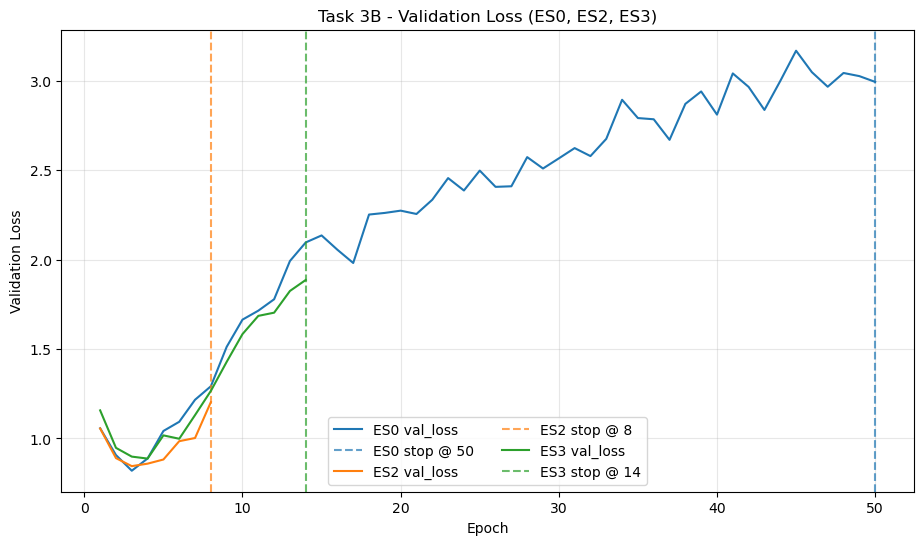

In [14]:
# Deliverable 24: val loss curves + stopping points
plt.figure(figsize=(11, 6))
colors = {'ES0': 'tab:blue', 'ES2': 'tab:orange', 'ES3': 'tab:green'}

for exp in ['ES0', 'ES2', 'ES3']:
    losses = es_histories[exp].history['val_loss']
    stop_epoch = len(losses)
    epochs = np.arange(1, stop_epoch + 1)

    plt.plot(epochs, losses, label=f'{exp} val_loss', color=colors[exp])
    plt.axvline(stop_epoch, color=colors[exp], linestyle='--', alpha=0.7,
                label=f'{exp} stop @ {stop_epoch}')

plt.title('Task 3B - Validation Loss (ES0, ES2, ES3)')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.show()

### Task 3B Conclusion (Deliverable 25)

- **ES2** with patience = 5 isn't too aggressive.
- **ES3** with patience = 10 is too lenient.